In [3]:
import sys
print(sys.executable)

/opt/conda/envs/anaconda-ai-2025.12-py312/bin/python


In [20]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


# =========================
# 2. LOAD AND CLEAN DATA
# =========================
# Read file without assuming headers
df = pd.read_excel("Data.xlsx", header=None)

# Drop fully empty rows and columns
df = df.dropna(how="all")
df = df.dropna(axis=1, how="all")
df = df.reset_index(drop=True)

# First row becomes header
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Clean column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(".", "_", regex=False)
)

print("Columns:")
print(df.columns.tolist())


# =========================
# 3. CONVERT DATA TYPES
# =========================
# Convert all columns except City to numeric
numeric_cols = [col for col in df.columns if col != "City"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Make target explicitly integer
df["Personal_Loan"] = df["Personal_Loan"].astype(int)

print("\nData info:")
print(df.info())


# =========================
# 4. SELECT FEATURES AND TARGET
# =========================
# IMPORTANT: Do NOT include Personal_Loan in features
features = [
    "Age",
    "Experience",
    "Family",
    "CCAvg",
    "Education",
    "Mortgage",
    "Securities_Account",
    "CD_Account",
    "Online",
    "CreditCard",
    "Median_Income_Per_City",
    "Income_/_Median_in_city"
]

target = "Personal_Loan"

# Keep only needed columns and drop missing values
data = df[features + [target]].dropna().copy()

X = data[features].values
y = data[target].values

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Unique target values:", np.unique(y))


# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 6. STANDARDIZE FEATURES
# =========================
# Fit only on training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================
# 7. RESHAPE FOR CNN
# =========================
# CNN input shape = (samples, features, channels)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


# =========================
# 8. BUILD CNN MODEL
# =========================
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Conv1D(filters=32, kernel_size=2, activation="relu"),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])


# =========================
# 9. COMPILE MODEL
# =========================
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# =========================
# 10. TRAIN MODEL
# =========================
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# =========================
# 11. MAKE PREDICTIONS
# =========================
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)

# =========================
# 12. EVALUATE MODEL
# =========================
print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Columns:
['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   float64
 1   Experience               5000 non-null   float64
 2   City                     5000 non-null   object 
 3   Family                   5000 non-null   float64
 4   CCAvg                    5000 non-null   float64
 5   Education                5000 non-null   float64
 6   Mortgage                 5000 non-null   float64
 7   Personal_Loan            5000 non-null   int64  
 8   Securities_Account       5000 non-null   int64  
 9   CD_Account               5000 non-null   int64  
 10  Online         

In [5]:
!pip uninstall -y protobuf


Found existing installation: protobuf 3.20.3
Uninstalling protobuf-3.20.3:
  Successfully uninstalled protobuf-3.20.3


In [6]:
!pip install protobuf==3.20.3


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)


In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

In [8]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


# =========================
# 2. LOAD DATA
# =========================
# Load everything without assuming a header
df = pd.read_excel("Data.xlsx", header=None)

# Drop fully empty rows and columns
df = df.dropna(how='all')
df = df.dropna(axis=1, how='all')
df = df.reset_index(drop=True)

# Set first row as header
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Clean column names
df.columns = df.columns.astype(str).str.strip().str.replace(' ', '_').str.replace('.', '_', regex=False)

print(df.columns.tolist())


# =========================
# 3. DATA CLEANING
# =========================
# Convert all columns except City to numeric
numeric_cols = df.columns.drop('City')
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Check structure
df.info()


# =========================
# 4. SELECT VARIABLES
# =========================
features = [
    'Age', 'Experience', 'Family', 'CCAvg', 'Education',
    'Mortgage', 'Securities_Account', 'CD_Account',
    'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city'
]

target = 'Personal_Loan'

# Keep only needed columns and drop missing values
data = df[features + [target]].dropna()

X = data[features].values
y = data[target].values


# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 6. RESHAPE FOR CNN
# =========================
# CNN expects: (samples, features, channels)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


# =========================
# 7. BUILD CNN MODEL
# =========================
model = Sequential()

model.add(Conv1D(
    filters=32,
    kernel_size=2,
    activation='relu',
    input_shape=(X_train.shape[1], 1)
))

model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))


# =========================
# 8. COMPILE MODEL
# =========================
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# =========================
# 9. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)


# =========================
# 10. PREDICTIONS
# =========================
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)


# =========================
# 11. EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   float64
 1   Experience               5000 non-null   float64
 2   City                     5000 non-null   object 
 3   Family                   5000 non-null   float64
 4   CCAvg                    5000 non-null   float64
 5   Education                5000 non-null   float64
 6   Mortgage                 5000 non-null   float64
 7   Personal_Loan            5000 non-null   int64  
 8   Securities_Account       5000 non-null   int64  
 9   CD_Account               5000 non-null   int64  
 10  Online                   5000 non-nu

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9025 - loss: 0.3179 - val_accuracy: 0.9162 - val_loss: 0.2256
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9150 - loss: 0.2429 - val_accuracy: 0.9375 - val_loss: 0.1985
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9253 - loss: 0.2208 - val_accuracy: 0.9325 - val_loss: 0.2090
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9269 - loss: 0.2135 - val_accuracy: 0.9325 - val_loss: 0.1916
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9287 - loss: 0.2067 - val_accuracy: 0.9337 - val_loss: 0.1853
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9294 - loss: 0.2059 - val_accuracy: 0.9362 - val_loss: 0.1795
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9322 - loss: 0.1975 - val_accuracy: 0.9300 - val_loss: 0.1972
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9300 - loss: 0.2049 - val_accuracy: 0.9362 - val_

In [23]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_excel("Data.xlsx", header=None)

# Drop fully empty rows and columns
df = df.dropna(how='all')
df = df.dropna(axis=1, how='all')
df = df.reset_index(drop=True)

# Set first row as header
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Clean column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('.', '_', regex=False)
)

print(df.columns.tolist())

# =========================
# 3. CLEAN DATA TYPES
# =========================
# Convert all columns except City to numeric
numeric_cols = [col for col in df.columns if col != 'City']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Make target explicitly integer
df['Personal_Loan'] = df['Personal_Loan'].astype(int)

df.info()

# =========================
# 4. SELECT VARIABLES
# =========================
features = [
    'Age', 'Experience', 'Family', 'CCAvg', 'Education',
    'Mortgage', 'Securities_Account', 'CD_Account',
    'Online', 'CreditCard', 'Median_Income_Per_City',
    'Income_/_Median_in_city'
]

target = 'Personal_Loan'

# Keep only needed columns
data = df[features + [target]].dropna().copy()

# X and y
X = data[features]
y = data[target].astype(int)

print("\nUnique values in target:", y.unique())
print("Target dtype:", y.dtype)

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 6. RANDOM FOREST MODEL
# =========================
rf = RandomForestClassifier(
    n_estimators=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# =========================
# 7. PREDICTIONS
# =========================
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

# =========================
# 8. EVALUATION
# =========================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   float64
 1   Experience               5000 non-null   float64
 2   City                     5000 non-null   object 
 3   Family                   5000 non-null   float64
 4   CCAvg                    5000 non-null   float64
 5   Education                5000 non-null   float64
 6   Mortgage                 5000 non-null   float64
 7   Personal_Loan            5000 non-null   int64  
 8   Securities_Account       5000 non-null   int64  
 9   CD_Account               5000 non-null   int64  
 10  Online                   5000 non-nu

In [10]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                    Feature  Importance
11  Income_/_Median_in_city    0.244869
3                     CCAvg    0.213167
4                 Education    0.136317
10   Median_Income_Per_City    0.097405
2                    Family    0.078637
7                CD_Account    0.068778
1                Experience    0.045444
5                  Mortgage    0.044997
0                       Age    0.043819
9                CreditCard    0.011128
8                    Online    0.009255
6        Securities_Account    0.006183


In [11]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_excel("Data.xlsx", header=None)

# Drop fully empty rows and columns
df = df.dropna(how='all')
df = df.dropna(axis=1, how='all')
df = df.reset_index(drop=True)

# Set first row as header
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Clean column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('.', '_', regex=False)
)

print(df.columns.tolist())

# =========================
# 3. CLEAN DATA TYPES
# =========================
numeric_cols = [col for col in df.columns if col != 'City']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df['Personal_Loan'] = df['Personal_Loan'].astype(int)

df.info()

# =========================
# 4. SELECT VARIABLES
# =========================
features = [
    'Age', 'Experience', 'Family', 'CCAvg', 'Education',
    'Mortgage', 'Securities_Account', 'CD_Account',
    'Online', 'CreditCard', 'Median_Income_Per_City',
    'Income_/_Median_in_city'
]

target = 'Personal_Loan'

data = df[features + [target]].dropna().copy()

X = data[features]
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique y values:", y.unique())

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 6. LOGISTIC REGRESSION
# =========================
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

# =========================
# 7. PREDICTIONS
# =========================
y_prob = lr.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

# =========================
# 8. EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   float64
 1   Experience               5000 non-null   float64
 2   City                     5000 non-null   object 
 3   Family                   5000 non-null   float64
 4   CCAvg                    5000 non-null   float64
 5   Education                5000 non-null   float64
 6   Mortgage                 5000 non-null   float64
 7   Personal_Loan            5000 non-null   int64  
 8   Securities_Account       5000 non-null   int64  
 9   CD_Account               5000 non-null   int64  
 10  Online                   5000 non-nu

In [12]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_excel("Data.xlsx", header=None)

# Drop fully empty rows
df = df.dropna(how='all')

# Drop fully empty columns
df = df.dropna(axis=1, how='all')

# Reset index
df = df.reset_index(drop=True)

# Set first row as header
df.columns = df.iloc[0]

# Remove header row from data
df = df[1:].reset_index(drop=True)

# Clean column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('.', '_', regex=False)
)

print(df.columns.tolist())

# =========================
# 3. CONVERT DATA TYPES
# =========================
numeric_cols = [col for col in df.columns if col != 'City']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Make target explicitly binary integer
df['Personal_Loan'] = df['Personal_Loan'].astype(int)

print(df.info())

# =========================
# 4. SELECT VARIABLES
# =========================
features = [
    'Age', 'Experience', 'Family', 'CCAvg', 'Education',
    'Mortgage', 'Securities_Account', 'CD_Account',
    'Online', 'CreditCard', 'Median_Income_Per_City',
    'Income_/_Median_in_city'
]

target = 'Personal_Loan'

# Keep only relevant columns and drop missing values
data = df[features + [target]].dropna().copy()

X = data[features]
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique target values:", y.unique())
print("Target dtype:", y.dtype)

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 6. GRADIENT BOOSTING MODEL
# =========================
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

# =========================
# 7. PREDICTIONS
# =========================
y_prob = gb.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

# =========================
# 8. EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   float64
 1   Experience               5000 non-null   float64
 2   City                     5000 non-null   object 
 3   Family                   5000 non-null   float64
 4   CCAvg                    5000 non-null   float64
 5   Education                5000 non-null   float64
 6   Mortgage                 5000 non-null   float64
 7   Personal_Loan            5000 non-null   int64  
 8   Securities_Account       5000 non-null   int64  
 9   CD_Account               5000 non-null   int64  
 10  Online                   5000 non-nu

Boosting AUC: 0.9937488477138644


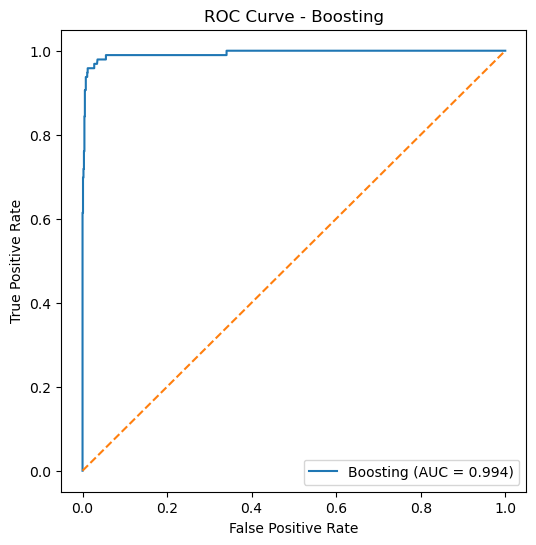

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities from Boosting
# Example:
y_prob_gb = gb.predict_proba(X_test)[:, 1]

fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Boosting AUC:", auc_gb)

plt.figure(figsize=(6,6))
plt.plot(fpr_gb, tpr_gb, label=f"Boosting (AUC = {auc_gb:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Boosting")
plt.legend()
plt.show()

Random Forest AUC: 0.9948147123893806


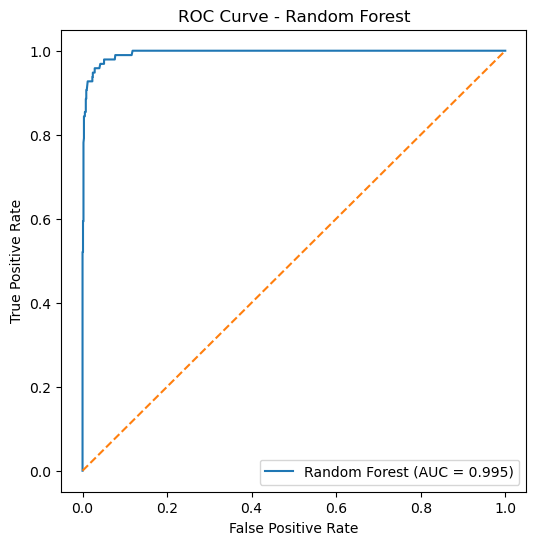

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities from Random Forest
# Example:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest AUC:", auc_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

Logistic Regression AUC: 0.9495529129793512


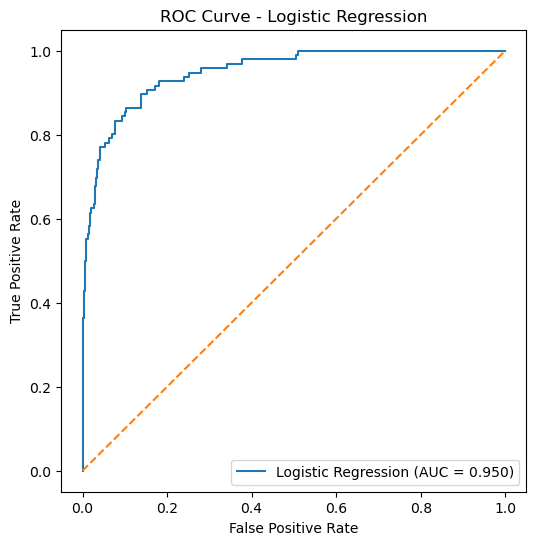

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities from Logistic Regression
# Example:
y_prob_log = lr.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression AUC:", auc_log)

plt.figure(figsize=(6,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [16]:
#Using Sigmoid in both hidden and Output Layers ! Even Worse!

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

torch.set_num_threads(1)

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_excel("Data.xlsx")

# Clean column names
df.columns = df.columns.str.strip()

# Step 1: Load everything without assuming a header
df = pd.read_excel('Data.xlsx', header=None)

# Step 2: Drop fully empty rows
df = df.dropna(how='all')

# Step 3: Drop fully empty columns (if any)
df = df.dropna(axis=1, how='all')

# Step 4: Reset index
df = df.reset_index(drop=True)

# Step 5: Set first row as header
df.columns = df.iloc[0]

# Step 6: Remove the header row from data
df = df[1:]

# Step 7: Reset index
df = df.reset_index(drop=True)

# Optional: clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('.', '_')

print(df.columns.tolist())

# =========================
# 3. SELECT VARIABLES
# =========================
features = [
    'Age', 'Experience', 'Family', 'CCAvg', 'Education',
    'Mortgage', 
    'Securities_Account', 'CD_Account',
    'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city'
]

target = 'Personal_Loan'

data = df[features + [target]].dropna()

# Convert all columns except 'City' to numeric
numeric_cols = df.columns.drop('City')
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

df.info()

X = data[features].values.astype(np.float32)
y = data[target].values.astype(np.float32)

# Scale inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Same 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Reshape for 1D CNN in PyTorch: (batch, channels, sequence_length)
X_train_t = torch.tensor(X_train).unsqueeze(1)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_train_t = torch.tensor(y_train).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# CNN with sigmoid hidden layers + sigmoid output
class SigmoidCNN(nn.Module):
    def __init__(self, input_len):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 4, kernel_size=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        conv_out_len = input_len - 2 + 1
        pooled_len = conv_out_len // 2
        self.fc1 = nn.Linear(4 * pooled_len, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.sigmoid(self.conv1(x))  # hidden layer sigmoid
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))    # hidden layer sigmoid
        x = torch.sigmoid(self.fc2(x))    # output layer sigmoid
        return x

torch.manual_seed(42)
model = SigmoidCNN(input_len=X_train.shape[1])

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train
for epoch in range(25):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

# Evaluate
model.eval()
with torch.no_grad():
    y_prob = model(X_test_t).squeeze().numpy()

y_pred = (y_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   float64
 1   Experience               5000 non-null   float64
 2   City                     5000 non-null   object 
 3   Family                   5000 non-null   float64
 4   CCAvg                    5000 non-null   float64
 5   Education                5000 non-null   float64
 6   Mortgage                 5000 non-null   float64
 7   Personal_Loan            5000 non-null   int64  
 8   Securities_Account       5000 non-null   int64  
 9   CD_Account               5000 non-null   int64  
 10  Online                   5000 non-nu

In [17]:
#Using Sigmoid in both hidden and Output Layers but applying different Thresholds 

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

torch.set_num_threads(1)
torch.manual_seed(42)

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_excel("Data.xlsx")

# Clean column names
df.columns = df.columns.str.strip()

# Step 1: Load everything without assuming a header
df = pd.read_excel('Data.xlsx', header=None)

# Step 2: Drop fully empty rows
df = df.dropna(how='all')

# Step 3: Drop fully empty columns (if any)
df = df.dropna(axis=1, how='all')

# Step 4: Reset index
df = df.reset_index(drop=True)

# Step 5: Set first row as header
df.columns = df.iloc[0]

# Step 6: Remove the header row from data
df = df[1:]

# Step 7: Reset index
df = df.reset_index(drop=True)

# Optional: clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('.', '_')

print(df.columns.tolist())

# =========================
# 3. SELECT VARIABLES
# =========================
features = [
    'Age', 'Experience', 'Family', 'CCAvg', 'Education',
    'Mortgage', 
    'Securities_Account', 'CD_Account',
    'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city'
]

target = 'Personal_Loan'

data = df[features + [target]].dropna()

# Convert all columns except 'City' to numeric
numeric_cols = df.columns.drop('City')
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

df.info()

X = data[features].values.astype(np.float32)
y = data[target].values.astype(np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train).unsqueeze(1)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_train_t = torch.tensor(y_train).unsqueeze(1)

class SigmoidCNNLogits(nn.Module):
    def __init__(self, input_len):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 4, kernel_size=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        conv_out_len = input_len - 2 + 1
        pooled_len = conv_out_len // 2
        self.fc1 = nn.Linear(4 * pooled_len, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.sigmoid(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return x

model = SigmoidCNNLogits(input_len=X_train.shape[1])

n_pos = float(y_train.sum())
n_neg = float(len(y_train) - y_train.sum())
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(40):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    logits_test = model(X_test_t).squeeze().numpy()
    y_prob = 1 / (1 + np.exp(-logits_test))

thresholds = [0.20, 0.30, 0.40, 0.50]

for threshold in thresholds:
    y_pred = (y_prob > threshold).astype(int)
    print("Threshold:", threshold)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(confusion_matrix(y_test, y_pred))
    print()

['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Median_Income_Per_City', 'Income_/_Median_in_city']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   float64
 1   Experience               5000 non-null   float64
 2   City                     5000 non-null   object 
 3   Family                   5000 non-null   float64
 4   CCAvg                    5000 non-null   float64
 5   Education                5000 non-null   float64
 6   Mortgage                 5000 non-null   float64
 7   Personal_Loan            5000 non-null   int64  
 8   Securities_Account       5000 non-null   int64  
 9   CD_Account               5000 non-null   int64  
 10  Online                   5000 non-nu